# EITN 2026 - MFM Group: Tutorial 1

In this tutorial, we will explore how the activity of a neuron can be described using mathematical models. We will first introduce the basic concepts needed to understand how neurons generate electrical activity and how this activity changes over time. We will then focus on the **E-GLIF (Extended Generalized Leaky Integrate-and-Fire)** model, an example of a computational model used to reproduce the characteristic firing behavior of different types of cerebellar neurons.

## 0. Setup Enviroment

In [52]:
!pip install -q condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [60]:
../!mamba install -y -c conda-forge nest-simulator cmake compilers libboost-headers "sysroot_linux-64<2.34"

conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache
[+] 0.0s
[+] 0.0s

Pinned packages:

  - python=3.13

Pinned packages:

  - python_abi[version="=3.13",build="*cp313*"]

Pinned packages:

  - cuda-version*.*

Pinned packages:

  - python=3.13


Transaction

  Prefix: /usr/local

  All requested packages already installed


Transaction starting
[+] 0.0s

Transaction finished



In [68]:
from google.colab import drive, output
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [69]:
import os
os.chdir("/content/drive/MyDrive/EITN_school_2026_MFM-main/Day1")

In [71]:
!pip install -r ../Colab/requirements.txt

  Using cached arborize-7.6.0-py3-none-any.whl
  Using cached nrn_patch-7.6.0-py3-none-any.whl
  Using cached nmodl_glia-7.6.0-py3-none-any.whl
  Using cached bsb_core-7.6.0-py3-none-any.whl
  Using cached bsb_hdf5-7.6.0-py3-none-any.whl
  Using cached bsb_json-7.6.0-py3-none-any.whl
  Using cached bsb_yaml-7.6.0-py3-none-any.whl
  Using cached bsb_otel-7.6.0-py3-none-any.whl
  Using cached bsb_nest-7.6.0-py3-none-any.whl
  Using cached bsb_native-7.4.0-cp310-abi3-linux_x86_64.whl
  Using cached bsb-7.6.0-py3-none-any.whl
  Cloning https://github.com/dbbs-lab/cerebellar-models.git (to revision feature/auto_mfm) to /tmp/pip-install-cro_8f1y/cerebellar-models_2c47b563dd434909acae26c527166957
  Running command git clone --filter=blob:none --quiet https://github.com/dbbs-lab/cerebellar-models.git /tmp/pip-install-cro_8f1y/cerebellar-models_2c47b563dd434909acae26c527166957
  Running command git checkout -b feature/auto_mfm --track origin/feature/auto_mfm
  Switched to a new branch 'feature/

In [72]:
!cerebellar-models build-nestml

Building NESTML models...

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

The computation had not completed because of the undecidable set membership is found in every candidates.
CMake Warning:
  Ignoring empty string ("") provided on the command line.


-- The CXX compiler identification is GNU 15.2.0
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
--

In [73]:
%matplotlib inline
%env MPLBACKEND=Agg

env: MPLBACKEND=Agg


In [74]:
from IPython.display import Image, display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import re

## 1. Theoretical Background

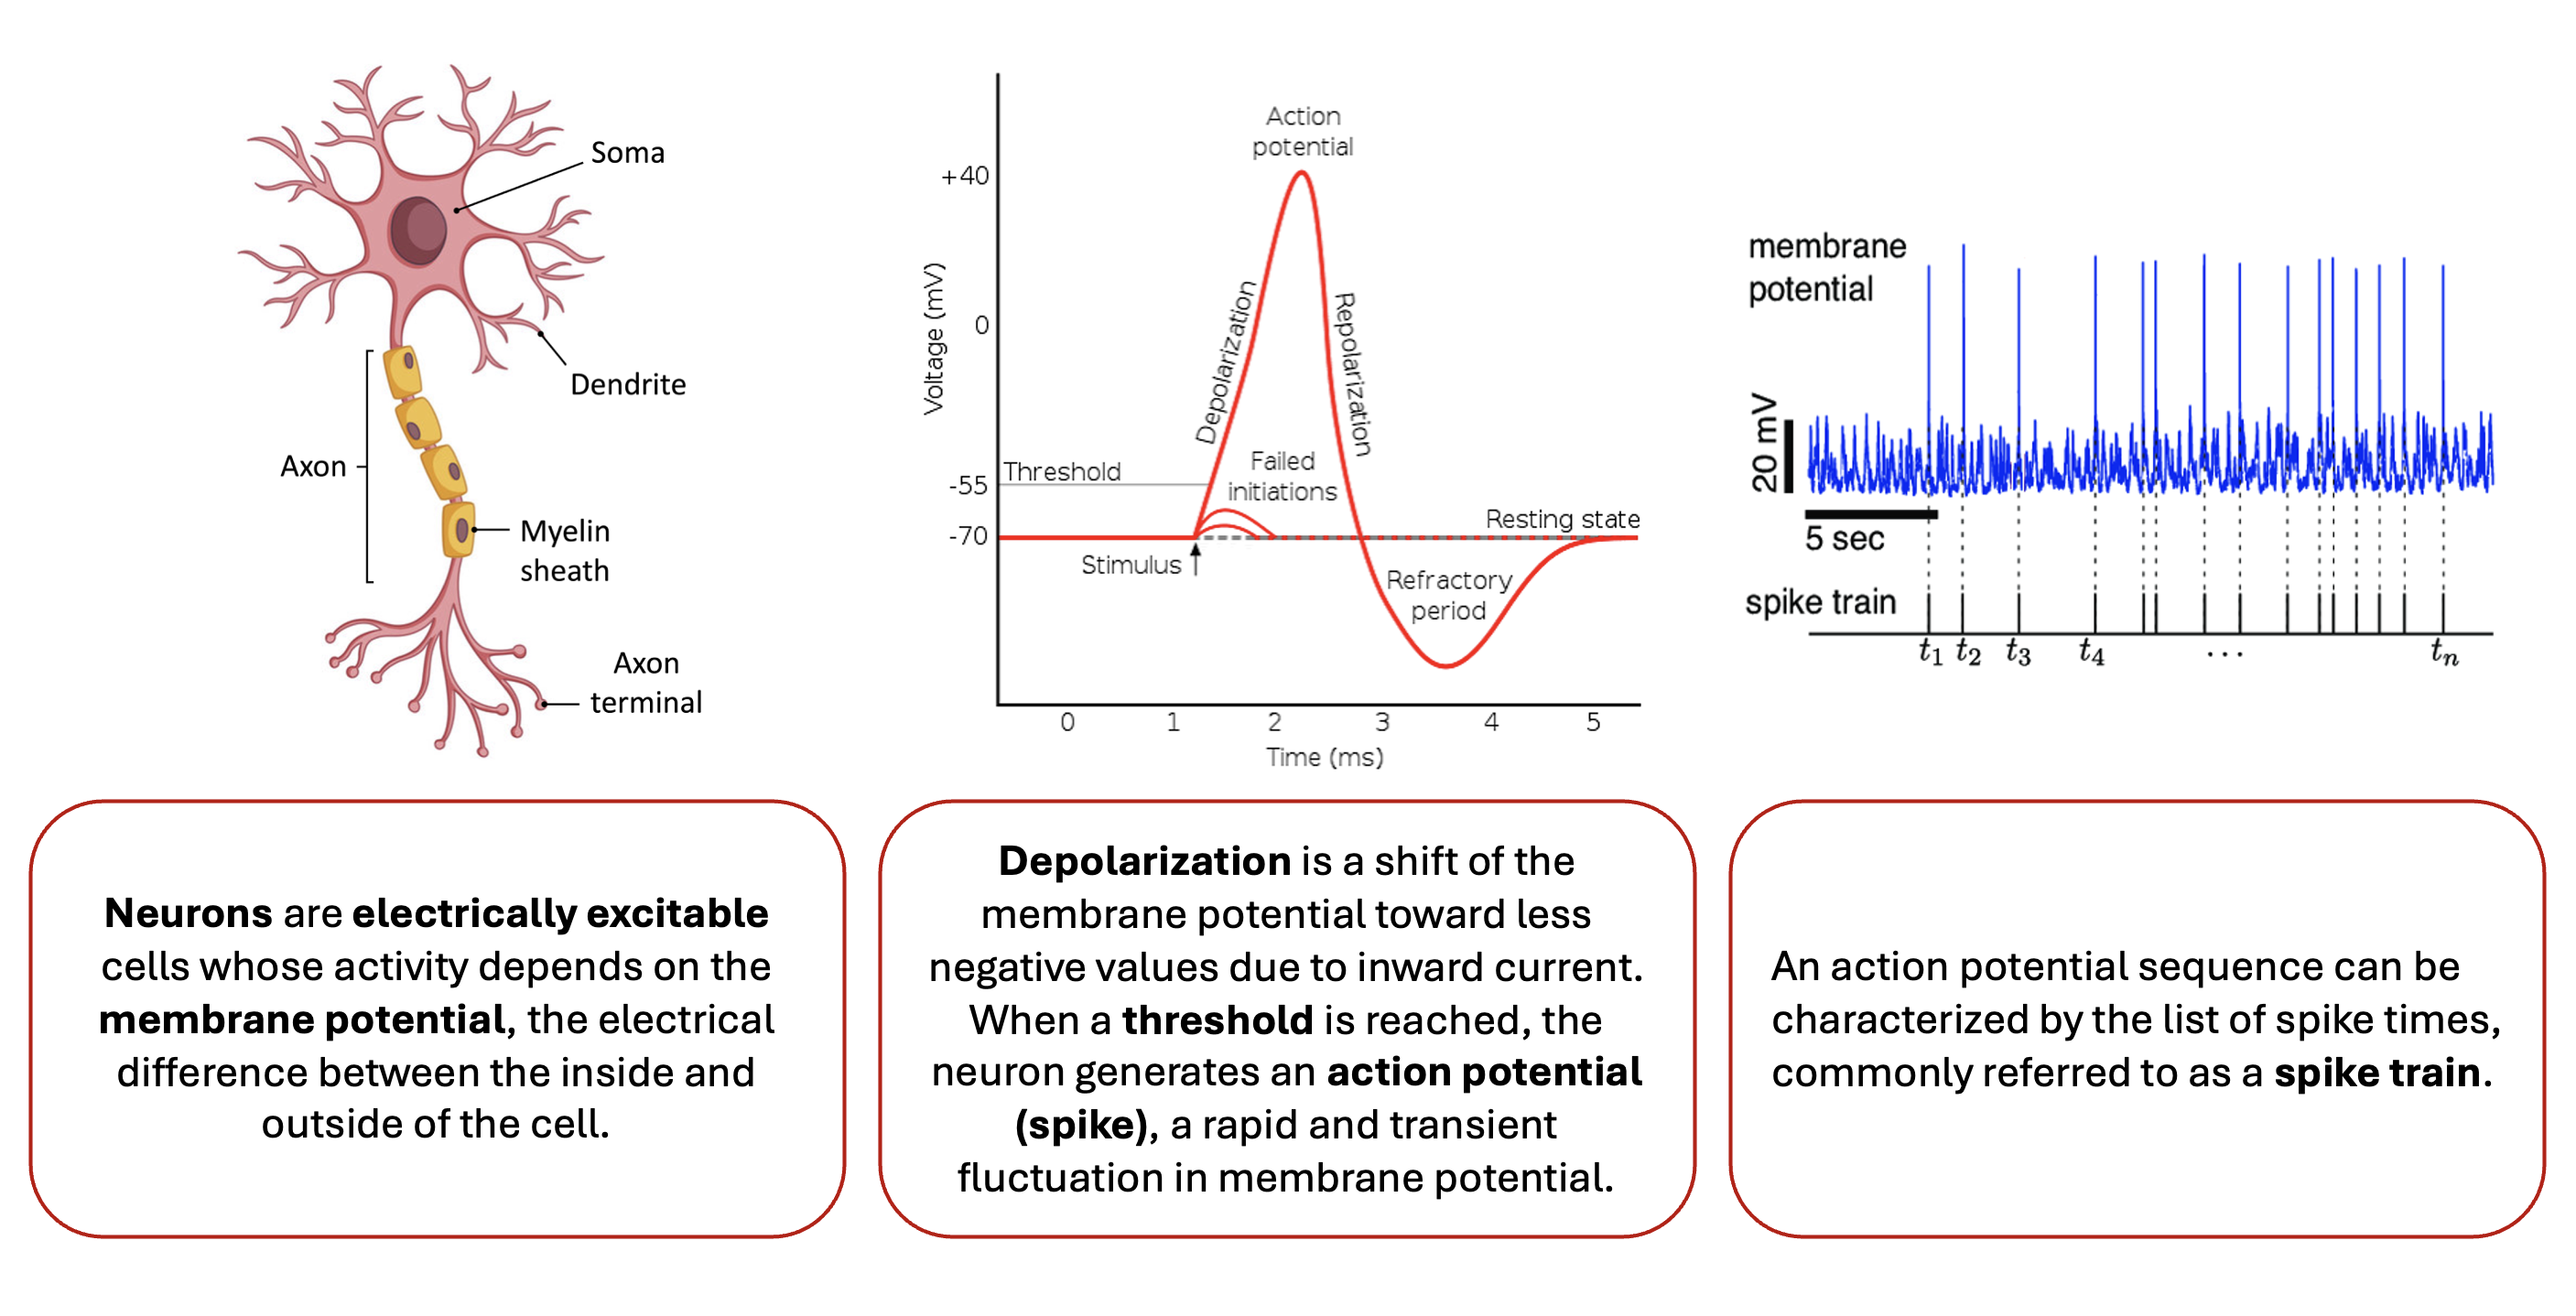

In [75]:
display(Image('figs/fig1.png'))

## 2. Leaky Integrate and Fire (LIF) model
A simple model for describing neuron **spiking activity** is the **Leaky Integrate-and-Fire (LIF)** model. Its main variable is the **membrane potential** of the soma V, which changes in response to incoming inputs. The neuron is modeled as an **RC circuit**: the capacitor integrates incoming currents, while the resistor accounts for the leakage toward the resting potential. When V reaches a predefined **threshold**, a **spike** is generated and V is reset.


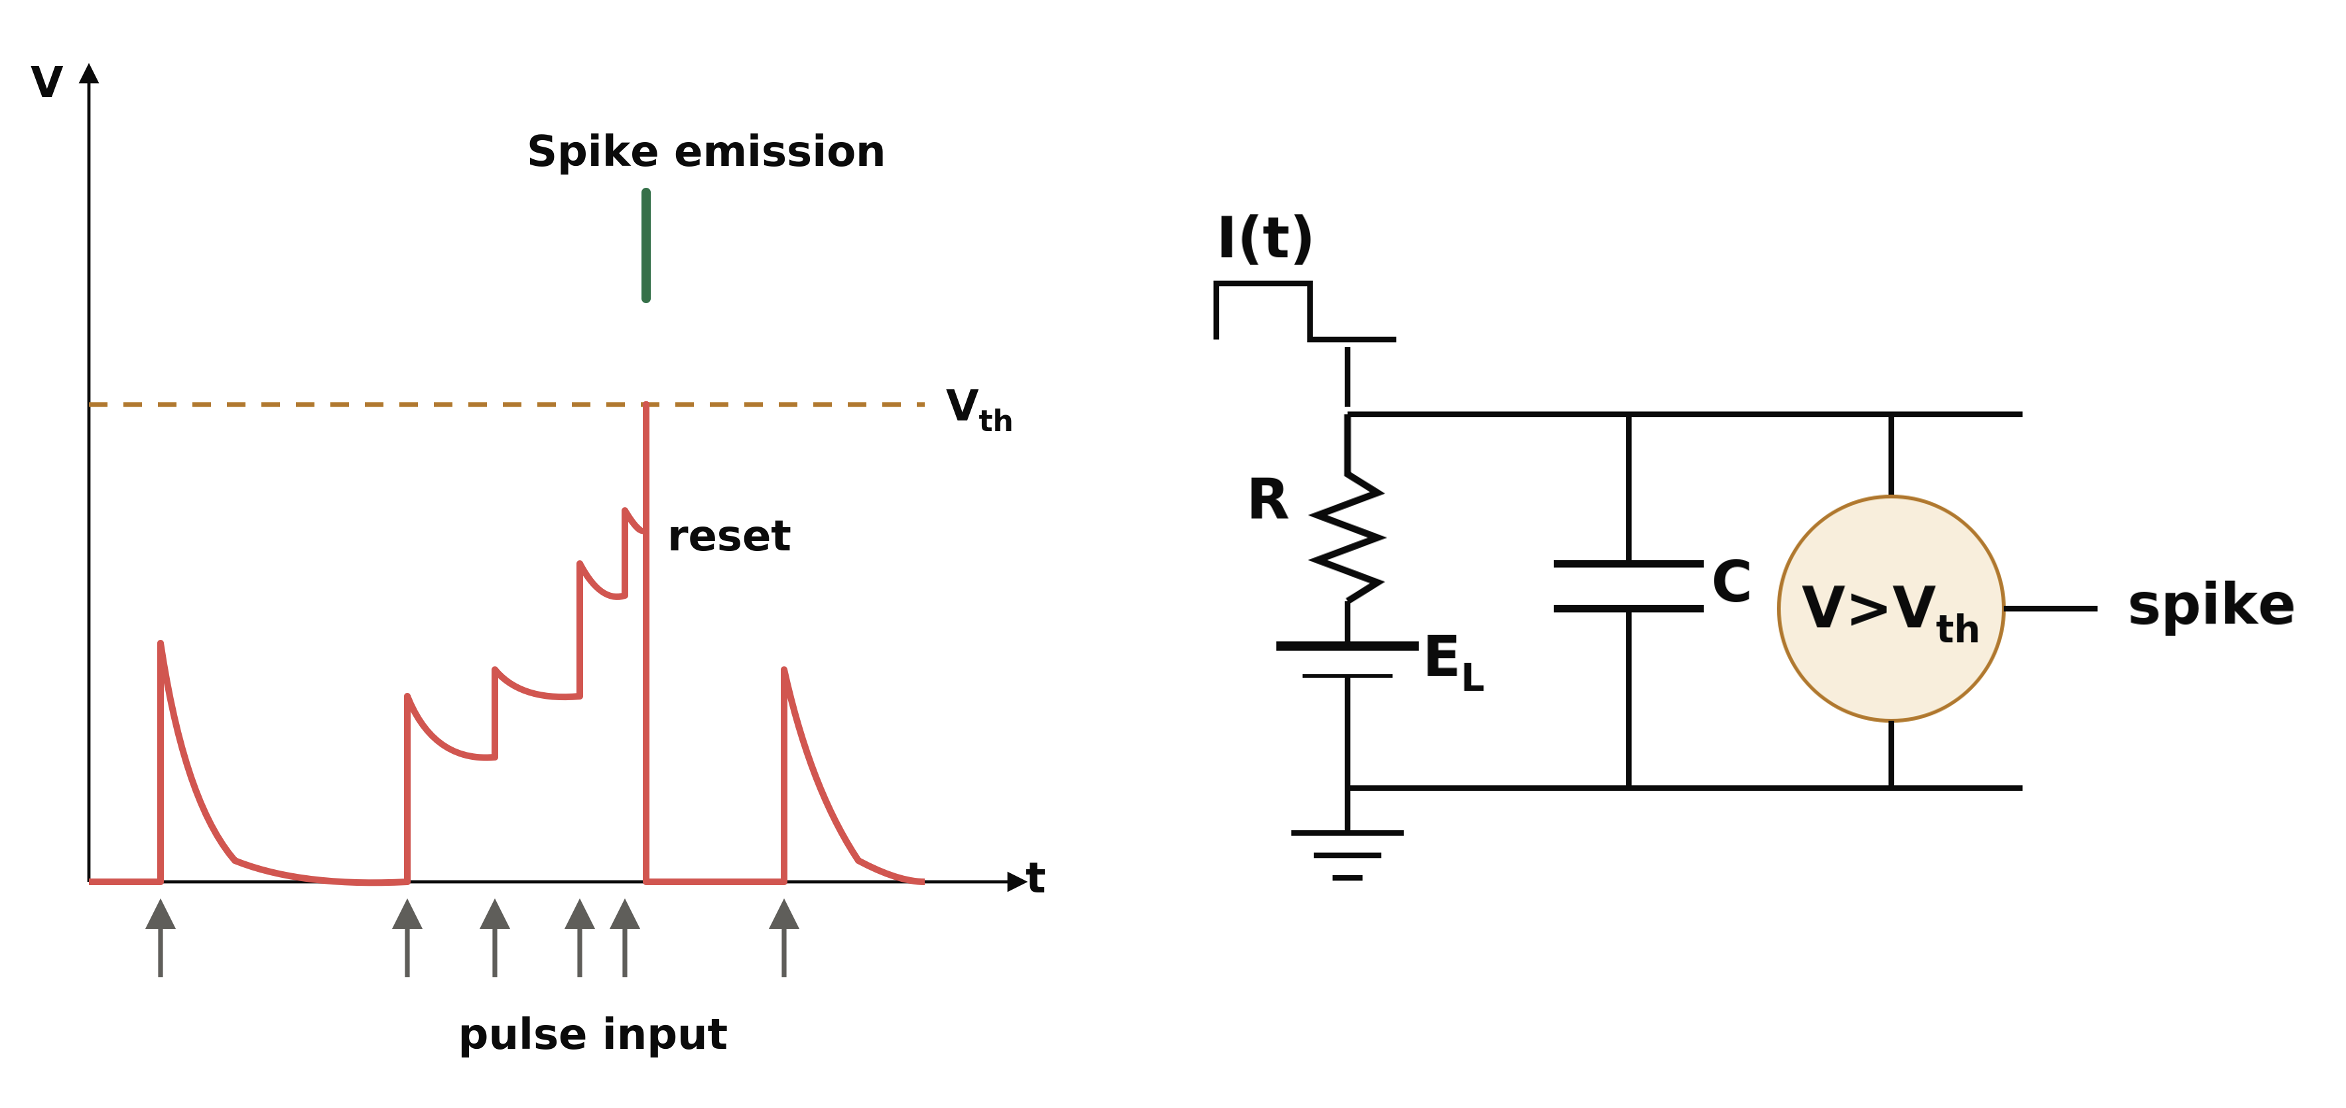

In [76]:
display(Image('figs/fig2.png'))

In the LIF model, the **subthreshold membrane potential** \(V\) evolves according to:

$$
C \frac{dV}{dt} = -g_L(V-E_L) + I
$$

or equivalently:

$$
\tau_m \frac{dV}{dt}=-(V-E_L) + \frac{I}{g_L}
$$

where:

- $C$ — membrane capacitance
- $g_L$ — leak conductance $\left(g_L = \frac{1}{R}\right)$
- $E_L$ — resting membrane potential
- $I$ — external input current
- $\tau_m = \frac{C_m}{g_L}$ - time constant

When the membrane potential reaches a threshold $V_{th}$, a **spike** is generated and $V$ is reset to a given value $V_{reset}$. The neuron then remains at $V_{reset}$ for a **refractory period** $\tau_{ref}$.

$$
V(t)=V_{reset}, \qquad
t\in[t_{sp},\,t_{sp}+\tau_{ref}]
$$


where $t_{sp}$ is the spike time.
<h2 style="font-size: 45px;">
🚀 Let's simulate it!
</h2>

In [77]:
pars = {}

# define typical nauronal parameters
pars['V_th'] = -55.     # spike threshold [mV]
pars['V_reset'] = -75.  # reset potential [mV]
pars['tau_m'] = 10.     # membrane time constant [ms]
pars['g_L'] = 10.       # leak conductance [nS]
pars['V_init'] = -75.   # initial potential [mV]
pars['E_L'] = -75.      # leak reversal potential [mV]
pars['tref'] = 2.       # refractory time [ms]

# simulation parameters
pars['sim_len'] = 1000.  # Total duration of simulation [ms]
pars['dt'] = .1          # Simulation time step [ms]
pars['t_steps'] = np.arange(0, pars['sim_len'], pars['dt'])  # Vector of discretized time points [ms]

In [78]:
def simulate_LIF(pars, I, stop=True):
    t = pars['t_steps'].size

    # Initialize voltage and current
    v = np.zeros(t)
    v[0] = pars['V_init']
    I = I * np.ones(t)

    if stop:  # set end of current to 0 if current pulse
        I[:int(len(I) / 2) - 1000] = 0
        I[int(len(I) / 2) + 1000:] = 0

    tr = 0.  # initialization of the count for refractory duration

    # Simulate the LIF dynamics
    rec_spikes = []  # array to record spike times
    for i in range(t - 1):
        if tr > 0:  # check for refractoriness
            v[i] = pars['V_reset']
            tr = tr - 1
        elif v[i] >= pars['V_th']:  # reset voltage and record spike event
            rec_spikes.append(i)
            v[i] = pars['V_reset']
            tr = pars['tref'] / pars['dt']

        # calculate the increment of the membrane potential
        dv = (-(v[i] - pars['E_L']) + I[i] / pars['g_L']) * (pars['dt'] / pars['tau_m'])

        # update the membrane potential
        v[i + 1] = v[i] + dv

    rec_spikes = np.array(rec_spikes) * pars['dt']

    return I, v, rec_spikes

In [79]:
def plot_volt_trace(pars, v, sp, I=None):
    V_th = pars['V_th']
    t_steps = pars['t_steps']

    if I is not None:
        fig, (ax1, ax2) = plt.subplots(
            2, 1, sharex=True, figsize=(8, 6),
            gridspec_kw={'height_ratios': [3, 1]}
        )
    else:
        fig, ax1 = plt.subplots(figsize=(8, 4))

    ax1.set_title('Membrane Potential')
    ax1.plot(t_steps, v, 'r')
    ax1.axhline(V_th, 0, 1, color='gray', ls='--')

    if len(sp) > 0:
        ax1.vlines(sp, V_th+1, V_th + 4, color='g', lw=2, label='Spike')

    ax1.set_ylabel('V [mV]')
    ax1.set_ylim([-80, -40])
    ax1.legend(['Membrane\npotential', r'Threshold V$_{\mathrm{th}}$', 'Spike'],
               loc=[1.05, 0.75])

    if I is not None:
        ax2.set_title('Injected current')
        ax2.plot(t_steps, I, 'b')
        ax2.set_xlabel('Time [ms]')
        ax2.set_ylabel('I [pA]')
        ax2.set_ylim([I.min() - 5, I.max() + 5])
    else:
        ax1.set_xlabel('Time [ms]')

    plt.tight_layout()

### 2.1 Subthreshold dynamics
A simple example of the response to a constant current step, without spike generation. We can observe the charging of the membrane during the input and its subsequent decay toward the resting potential due to membrane leakage.

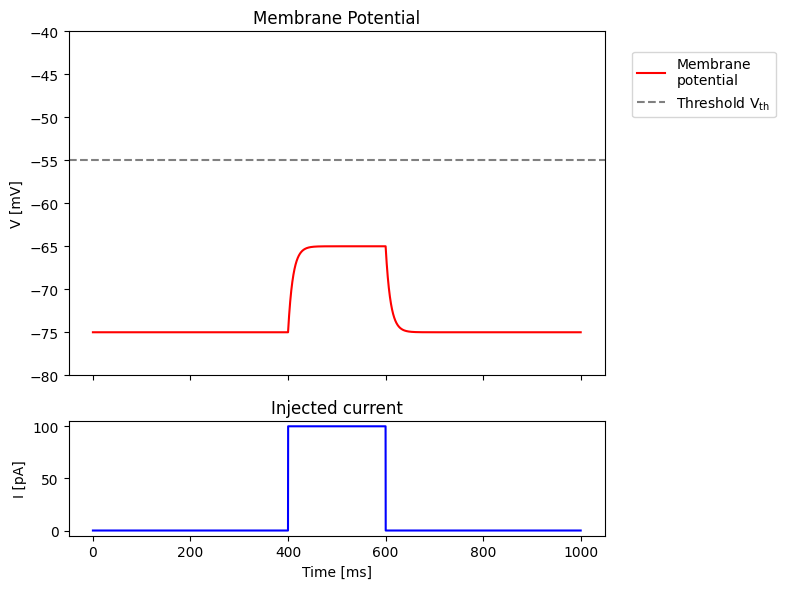

In [80]:
I_t, v, sp = simulate_LIF(pars, I=100, stop=True)
plot_volt_trace(pars, v, sp, I = I_t)
plt.show()

### 2.2 LIF neuron + DC current step
In this section, we will explore how a constant input current affects the activity of an LIF neuron. In particular, we will investigate:

- How much current is required for the neuron to reach threshold and start firing?
- How does the membrane time constant affect the neuron's spiking frequency?

In [81]:
def DC_input(I=200., tau_m=10.):
    pars['tau_m'] = tau_m
    I_t, v, sp = simulate_LIF(pars, I=I,stop=True)
    plot_volt_trace(pars, v, sp)
    plt.show()

## 3. Extendend Generalized Leak Integrated and Fire (EGLIF) model
We need a more complex model to reproduce a broader range of electroresponsive properties than a simple LIF model, including autorhythmicity, rebound firing, bursting, and spike-frequency adaptation.


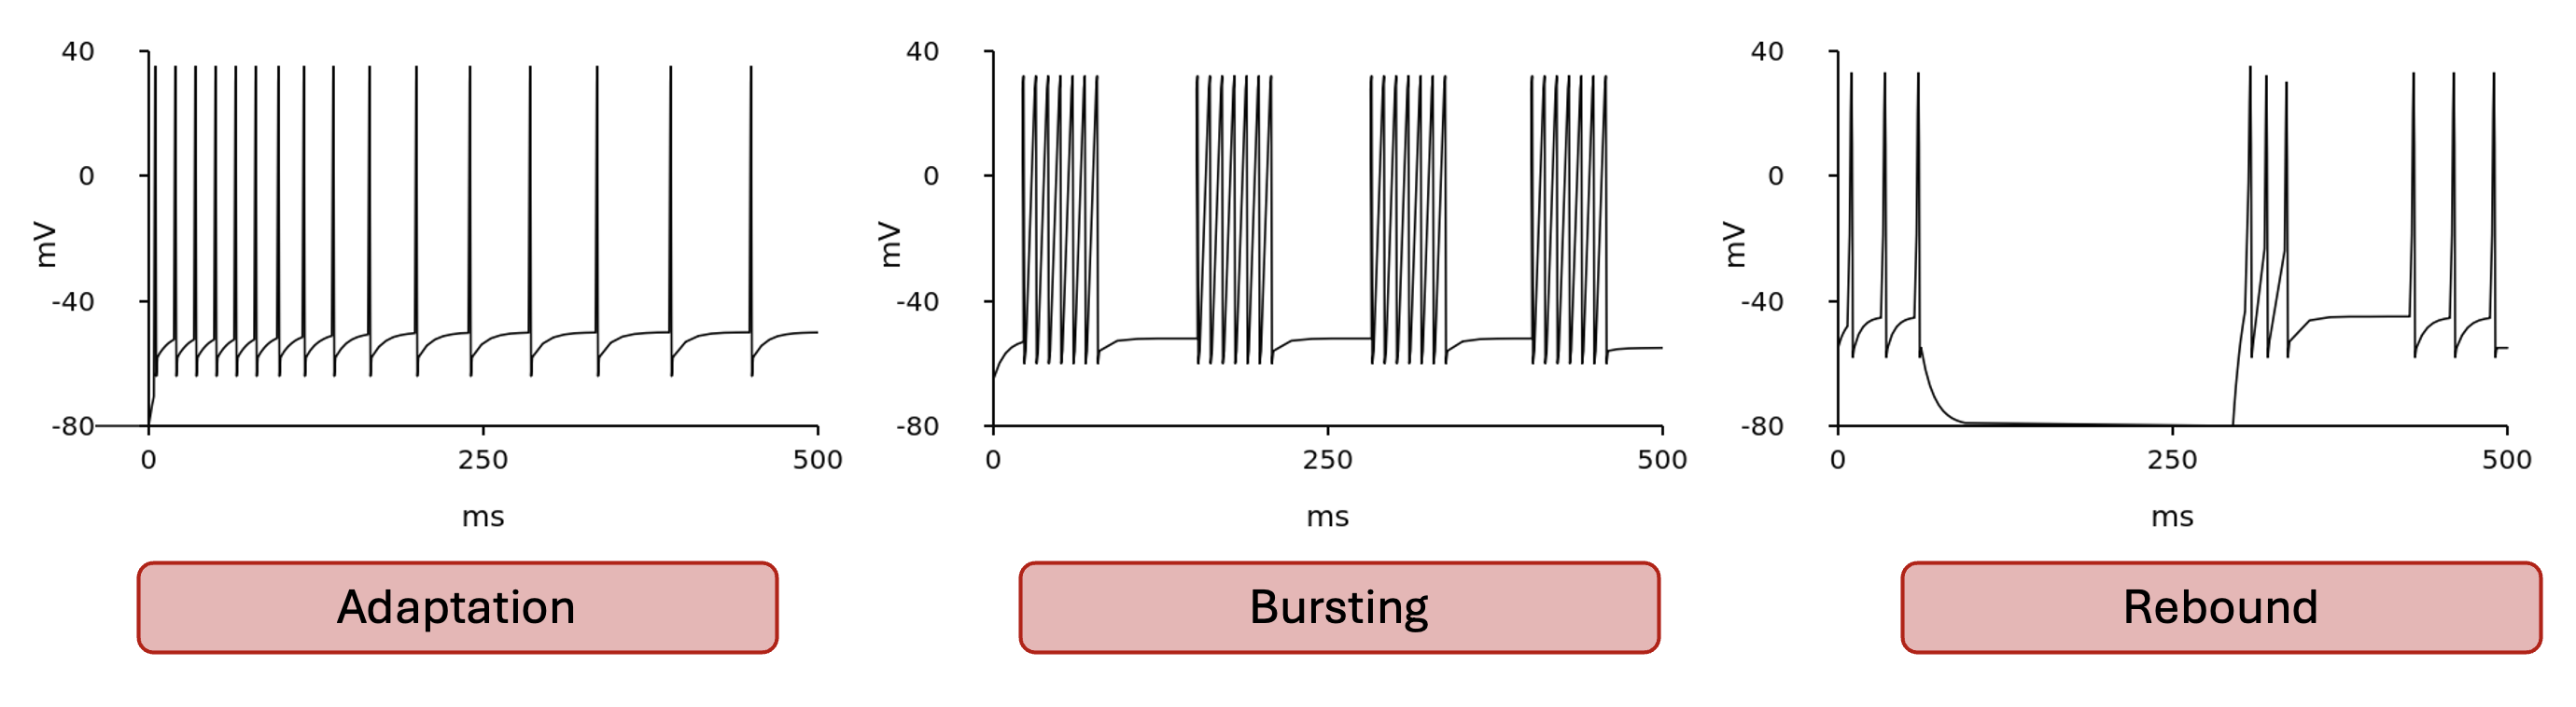

In [83]:
display(Image('figs/fig3.png'))

The model consists of a set of 3 differential equations describing the time evolution of:

1) **Membrane Potential** ($V$)
2) **Adaptation Current** ($I_{adap}$): reproduces the activation of potassium channels, generating a slow hyperpolarizing current;
3) **Depolarization Current** ($I_{dep}$): acts as a spike-triggered depolarizing current, mimicking the fast activation of sodium channels;


<h2 style="font-size: 25px;">
Model Equations
</h2>

The E-GLIF model is described by a system of 3 coupled linear ordinary differential equations:

$$
\begin{cases}
\dfrac{dV_m(t)}{dt} = \dfrac{1}{C_m}\left(\dfrac{C_m}{\tau_m}\big(V_m(t)-E_L\big) - I_{adap}(t) + I_{dep}(t) + I_e + I_{stim}\right) \\[8pt]
\dfrac{dI_{adap}(t)}{dt} = k_{adap}\big(V_m(t)-E_L\big) - k_2 \cdot I_{adap}(t) \\[8pt]
\dfrac{dI_{dep}(t)}{dt} = -k_1 \cdot I_{dep}(t)
\end{cases}
$$

where:
- $I_{stim}$ - external stimulation current
- $C_m$ - membrane capacitance
- $\tau_m$ - membrane time constant
- $E_L$ - resting potential
- $I_e$ - endogenous current (accounts for autorhythmicity)
- $k_{adap}, k_2$ - adaptation constants
- $k_1$ - $I_{dep}$ decay rate

**Spike generation:** if the neuron is not in the refractory period $\tau_{ref}$, a spike is generated at time $t_{spk}$.

**Update rules (post-spike reset):**

$$
\begin{cases}
V_m(t_{spk}^+) = V_r \\
I_{adap}(t_{spk}^+) = I_{adap}(t_{spk}) + A_2 \\
I_{dep}(t_{spk}^+) = A_1
\end{cases}
$$

where $V_r$ is the reset potential, and $A_1$, $A_2$ are the model currents' update (step) constants applied after each spike.

- **Fixed parameters** (directly measured neurophysiological quantities): $C_m, \tau_m, E_L, \tau_{ref}, V_{th}, V_r$.
- **Tunable parameters** (optimized for each specific cell type): $k_{adap}, k_2, k_1, A_1, A_2, I_e$.

### 3.1 Setting up the EGLIF simulator

In [84]:
eglif_pars = {}

# Fixed parameters
eglif_pars['C_m']     = 145.       # membrane capacitance [pF]
eglif_pars['tau_m']   = 44.        # membrane time constant [ms]
eglif_pars['E_L']     = -62.       # resting potential [mV]
eglif_pars['V_th']    = -55.       # spike threshold [mV]
eglif_pars['V_reset'] = -75.       # reset potential [mV]
eglif_pars['V_min']   = -350.      # lower voltage bound [mV]
eglif_pars['t_ref']   = 2.         # refractory period [ms]

# Tunable parameters
eglif_pars['I_e']     = 16.214     # endogenous current [pA]
eglif_pars['k_adap']  = 0.217      # adaptation gain
eglif_pars['k_2']     = 0.023      # I_adap decay rate [1/ms]
eglif_pars['k_1']     = 0.031      # I_dep decay rate [1/ms]
eglif_pars['A1']      = 259.988    # I_dep post-spike increment [pA]
eglif_pars['A2']      = 178.010    # I_adap post-spike increment [pA]

# Simulation defaults
eglif_pars['dt']     = 0.1
eglif_pars['V_init'] = eglif_pars['E_L']

In [85]:
def simulate_EGLIF(pars, I_stim=0., T=1000., dt=None, stim_start=None, stim_end=None):

    dt = pars['dt'] if dt is None else dt
    n = int(T / dt)
    t = np.arange(n) * dt

    # Initialize EGLIF state variables
    V = np.empty(n)
    I_adap = np.empty(n)
    I_dep = np.empty(n)
    V[0], I_adap[0], I_dep[0] = pars['V_init'], 0., 0.

    stim_window = (stim_start is not None) and (stim_end is not None)
    tr = 0.
    spikes = []

    for i in range(n - 1):
        I_ext = I_stim if (not stim_window or (stim_start <= t[i] < stim_end)) else 0.

        if tr > 0:                              # refractory period
            V[i] = pars['V_reset']
            tr -= 1
        elif V[i] >= pars['V_th']:              # spike emission + reset
            spikes.append(t[i])
            V[i] = pars['V_reset']
            I_dep[i] = pars['A1']
            I_adap[i] += pars['A2']
            tr = pars['t_ref'] / dt

        dV = (pars['C_m'] / pars['tau_m'] * (V[i] - pars['E_L'])
              - I_adap[i] + I_dep[i] + pars['I_e'] + I_ext) / pars['C_m']
        dIa = pars['k_adap'] * (V[i] - pars['E_L']) - pars['k_2'] * I_adap[i]
        dId = -pars['k_1'] * I_dep[i]

        V[i + 1] = max(V[i] + dV * dt, pars['V_min'])
        I_adap[i + 1] = I_adap[i] + dIa * dt
        I_dep[i + 1] = I_dep[i] + dId * dt

    return t, V, I_adap, I_dep, np.array(spikes)

In [86]:
def plot_eglif_trace(t, V, I_adap, I_dep, sp, V_th, stim_window=None, title=None):
    fig, (axV, axI) = plt.subplots(2, 1, sharex=True, figsize=(8, 6),
                                    gridspec_kw={'height_ratios': [3, 2]})
    if stim_window is not None:
        for ax in (axV, axI):
            ax.axvspan(*stim_window, color='0.9', zorder=0)

    axV.plot(t, V, 'r')
    axV.axhline(V_th, color='gray', ls='--')
    if len(sp):
        axV.vlines(sp, V_th + 1, V_th + 6, color='g', lw=2)
    axV.set_ylabel('V [mV]')
    axV.set_title(title or 'Membrane potential')
    axV.legend(['V(t)', r'$V_{th}$', 'spike'], loc=[1.02, 0.4])

    axI.plot(t, I_adap, color='tab:red', label=r'$I_{adap}$')
    axI.plot(t, I_dep, color='tab:blue', label=r'$I_{dep}$')
    axI.set_ylabel('I [pA]')
    axI.set_xlabel('Time [ms]')
    axI.legend(loc=[1.02, 0.3])

    plt.tight_layout()
    return fig

### 3.2 The role of EGLIF state variables and parameters

#### a) Autorhythmicity ($I_e$)
In the absence of external input, the endogenous current ($I_e$) provides the drive needed to sustain spontaneous activity. The membrane potential repeatedly reaches threshold, generating regular, self-sustained spiking without external stimulation. This reproduces the pacemaking activity characteristic of neurons such as cerebellar Golgi cells.

**Exercise:** Simulate the EGLIF neuron for different values of $I_e$ and quantify how the spontaneous firing rate changes. For each value:

- Run the simulation with no external stimulation ($I_{stim} = 0$) and extract the spike train;
- Compute the **spontaneous firing rate**:
$$
f_{spont}(I_e) = \frac{1000}{\langle \text{ISI} \rangle} \quad \text{[Hz]}
$$
- Plot $f_{spont}$ as a function of $I_e$ to characterize the relationship between the endogenous current and the pacemaking frequency.

In [87]:
def sim_I_e(I_e=16.214):
    eglif_pars['I_e'] = I_e
    t, V, Ia, Id, sp = simulate_EGLIF(eglif_pars, I_stim=0., T=800.)
    plot_eglif_trace(t, V, Ia, Id, sp, eglif_pars['V_th'],
                      title=r'Example of spontaneous firing')
    if len(sp) > 1:
      print(f"Intrinsic firing rate: {1000. / np.mean(np.diff(sp)):.1f} Hz")
    plt.show()

#### b) Spike-frequency adaptation ($A_2$, $k_{adap}$, $k_2$)
**Spike-frequency adaptation**: under sustained stimulation, many neurons show a progressive reduction of their firing frequency along the spike train. In EGLIF this is entirely driven by $I_{adap}$, whose dynamics involve three separate constants:

- **$A_2$**: discrete, spike-triggered jump;
- **$k_{adap}$**: continuous gain;
- **$k_2$**: decay (leak) rate of $I_{adap}$.

**Exercise:** Evaluate the effect of modifying the adaptation parameters. Define relevant spike train metrics such as the following, computed from the sequence of spike times $t_1, t_2, \dots, t_N$ and the corresponding inter-spike intervals $\text{ISI}_i = t_{i+1} - t_i$:

**Spontaneous firing rate** — mean firing rate computed from the ISIs preceding stimulus onset:
$$
f_{spont} = \frac{1000}{\langle \text{ISI} \rangle_{pre}} \quad \text{[Hz]}
$$

**First ISI** — the first inter-spike interval within the stimulation window:
$$
\text{ISI}_{first} = t_2 - t_1
$$

**Last ISI** — the last inter-spike interval within the stimulation window:
$$
\text{ISI}_{last} = t_N - t_{N-1}
$$

**Adaptation index** — normalized average difference between consecutive ISIs, quantifying how much the ISIs grow (or shrink) along the spike train:
$$
AI = \frac{1}{N-2}\sum_{i=2}^{N-1} \frac{\text{ISI}_i - \text{ISI}_{i-1}}{\text{ISI}_i + \text{ISI}_{i-1}}
$$

A value of $AI > 0$ indicates adaptation (progressively longer ISIs), $AI \approx 0$ indicates no adaptation, and $AI < 0$ indicates facilitation (progressively shorter ISIs).

In [90]:
variants = {
    'Control':      dict(eglif_pars),
    'A2 x 0.5':     dict(eglif_pars, A2=0.5 * eglif_pars['A2']),
    'A2 x 2':       dict(eglif_pars, A2=2 * eglif_pars['A2']),
    'k_adap x 0.5': dict(eglif_pars, k_adap=0.5 * eglif_pars['k_adap']),
    'k_adap x 2':   dict(eglif_pars, k_adap=2 * eglif_pars['k_adap']),
    'k_2 x 0.5':    dict(eglif_pars, k_2=0.5 * eglif_pars['k_2']),
    'k_2 x 2':      dict(eglif_pars, k_2=2 * eglif_pars['k_2']),
}

rows = {}
spike_trains = {}

for label, p in variants.items():
    _, _, _, _, sp = simulate_EGLIF(p, I_stim=300., T=1800., stim_start=800, stim_end=1800)
    rows[label] = {k: v for k, v in m.items() if k != 'isis'}
    spike_trains[label] = sp[(sp >= 800) & (sp <= 1800)]   # spikes during the stimulus window

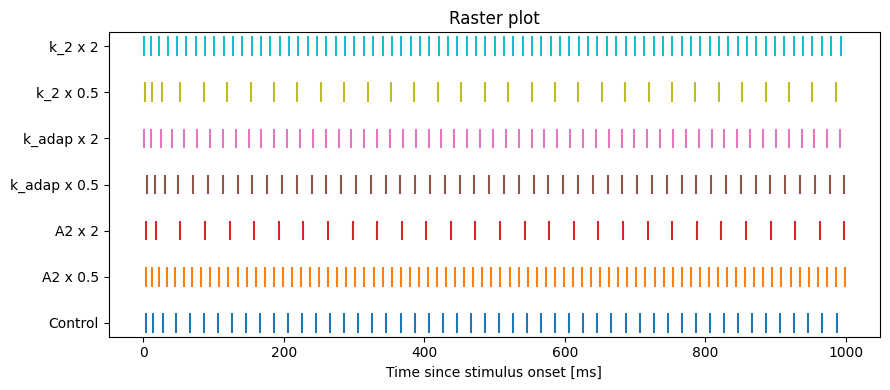

In [91]:
labels_list = list(variants.keys())
xs, ys = [], []
for i, label in enumerate(labels_list):
    sp = spike_trains[label]
    xs.extend(sp - 800.)          # time since stimulus onset
    ys.extend([i] * len(sp))      # one row per variant

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(xs, ys, c=ys, cmap='tab10', marker='|', s=200, linewidths=1.5)
ax.set_yticks(range(len(labels_list)))
ax.set_yticklabels(labels_list)
ax.set_xlabel('Time since stimulus onset [ms]')
ax.set_title('Raster plot')
plt.tight_layout()
plt.show()

#### c) Rebound firing after a hyperpolarizing step

A transient hyperpolarizing current can trigger a **rebound response** when released. The resulting depolarizing drive can initiate a spike, after which the fast spike-triggered current $I_{dep}$ helps sustain the rebound burst. Its contribution is controlled by $A_1$ (amplitude) and $k_1$ (decay rate).


In [93]:
variants = {
    'baseline':  dict(eglif_pars),
    'A1 x 0.5':  dict(eglif_pars, A1=0.5 * eglif_pars['A1']),
    'A1 x 2':    dict(eglif_pars, A1=2   * eglif_pars['A1']),
    'k_1 x 0.5': dict(eglif_pars, k_1=0.5 * eglif_pars['k_1']),
    'k_1 x 2':   dict(eglif_pars, k_1=2   * eglif_pars['k_1']),
}

results = {}
for label, p in variants.items():
    t, V, Ia, Id, sp = simulate_EGLIF(p, I_stim=-100., T=800., stim_start=0., stim_end=500.)
    post = sp[sp >= 500.]
    isis = np.diff(post)
    results[label] = dict(t=t, V=V, sp=sp,
                           rebound_freq=1000. / isis[0] if len(isis) else np.nan)

df_dep = pd.DataFrame({k: {'rebound_freq': v['rebound_freq']} for k, v in results.items()}).T

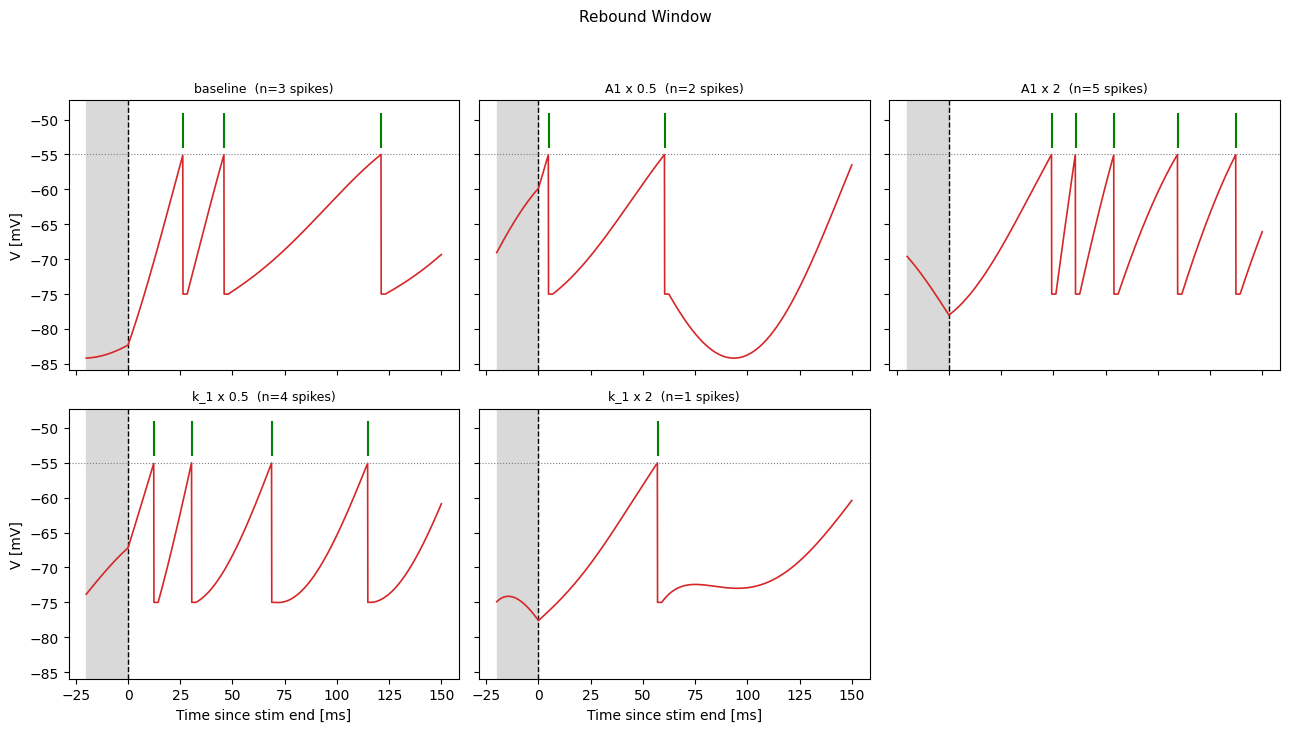

,rebound_freq
baseline,50.761421
A1 x 0.5,17.985612
A1 x 2,87.719298
k_1 x 0.5,55.248619
k_1 x 2,9.337068


In [94]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)

for ax, (label, r) in zip(axes.flat, results.items()):
    t, V, sp = r['t'], r['V'], r['sp']
    mask = (t >= 480.) & (t <= 650.)
    tw, Vw = t[mask] - 500., V[mask]

    ax.axvspan(tw[0], 0., color='0.85', zorder=0)
    ax.axvline(0., color='k', ls='--', lw=1.)
    ax.plot(tw, Vw, color='tab:red', lw=1.2)
    ax.axhline(eglif_pars['V_th'], color='gray', ls=':', lw=0.8)

    sp_post = sp[(sp >= 500.) & (sp <= 650.)]
    ax.vlines(sp_post - 500., eglif_pars['V_th'] + 1, eglif_pars['V_th'] + 6, color='g', lw=1.5)
    ax.set_title(f'{label}  (n={len(sp_post)} spikes)', fontsize=9)

axes.flat[-1].axis('off')
for ax in axes[:, 0]:
    ax.set_ylabel('V [mV]')
for ax in axes[1, :]:
    ax.set_xlabel('Time since stim end [ms]')

fig.suptitle(r'Rebound Window', y=1.04, fontsize=11)
plt.tight_layout()
plt.show()

df_dep

### 3.3 BONUS: Optimization of EGLIF Neurons Against Multicompartmental Models

The tunable parameters of the EGLIF model can be optimized for each specific neuronal population by using detailed multicompartmental models as reference. These models typically consist of hundreds of coupled differential equations, compared with only three equations in the EGLIF model.

The optimization aims to reproduce the main electrophysiological features of the population-specific neuronal response to standard **current-injection protocols**, including both depolarizing and hyperpolarizing stimuli, as well as the **spontaneous activity** of the cells.

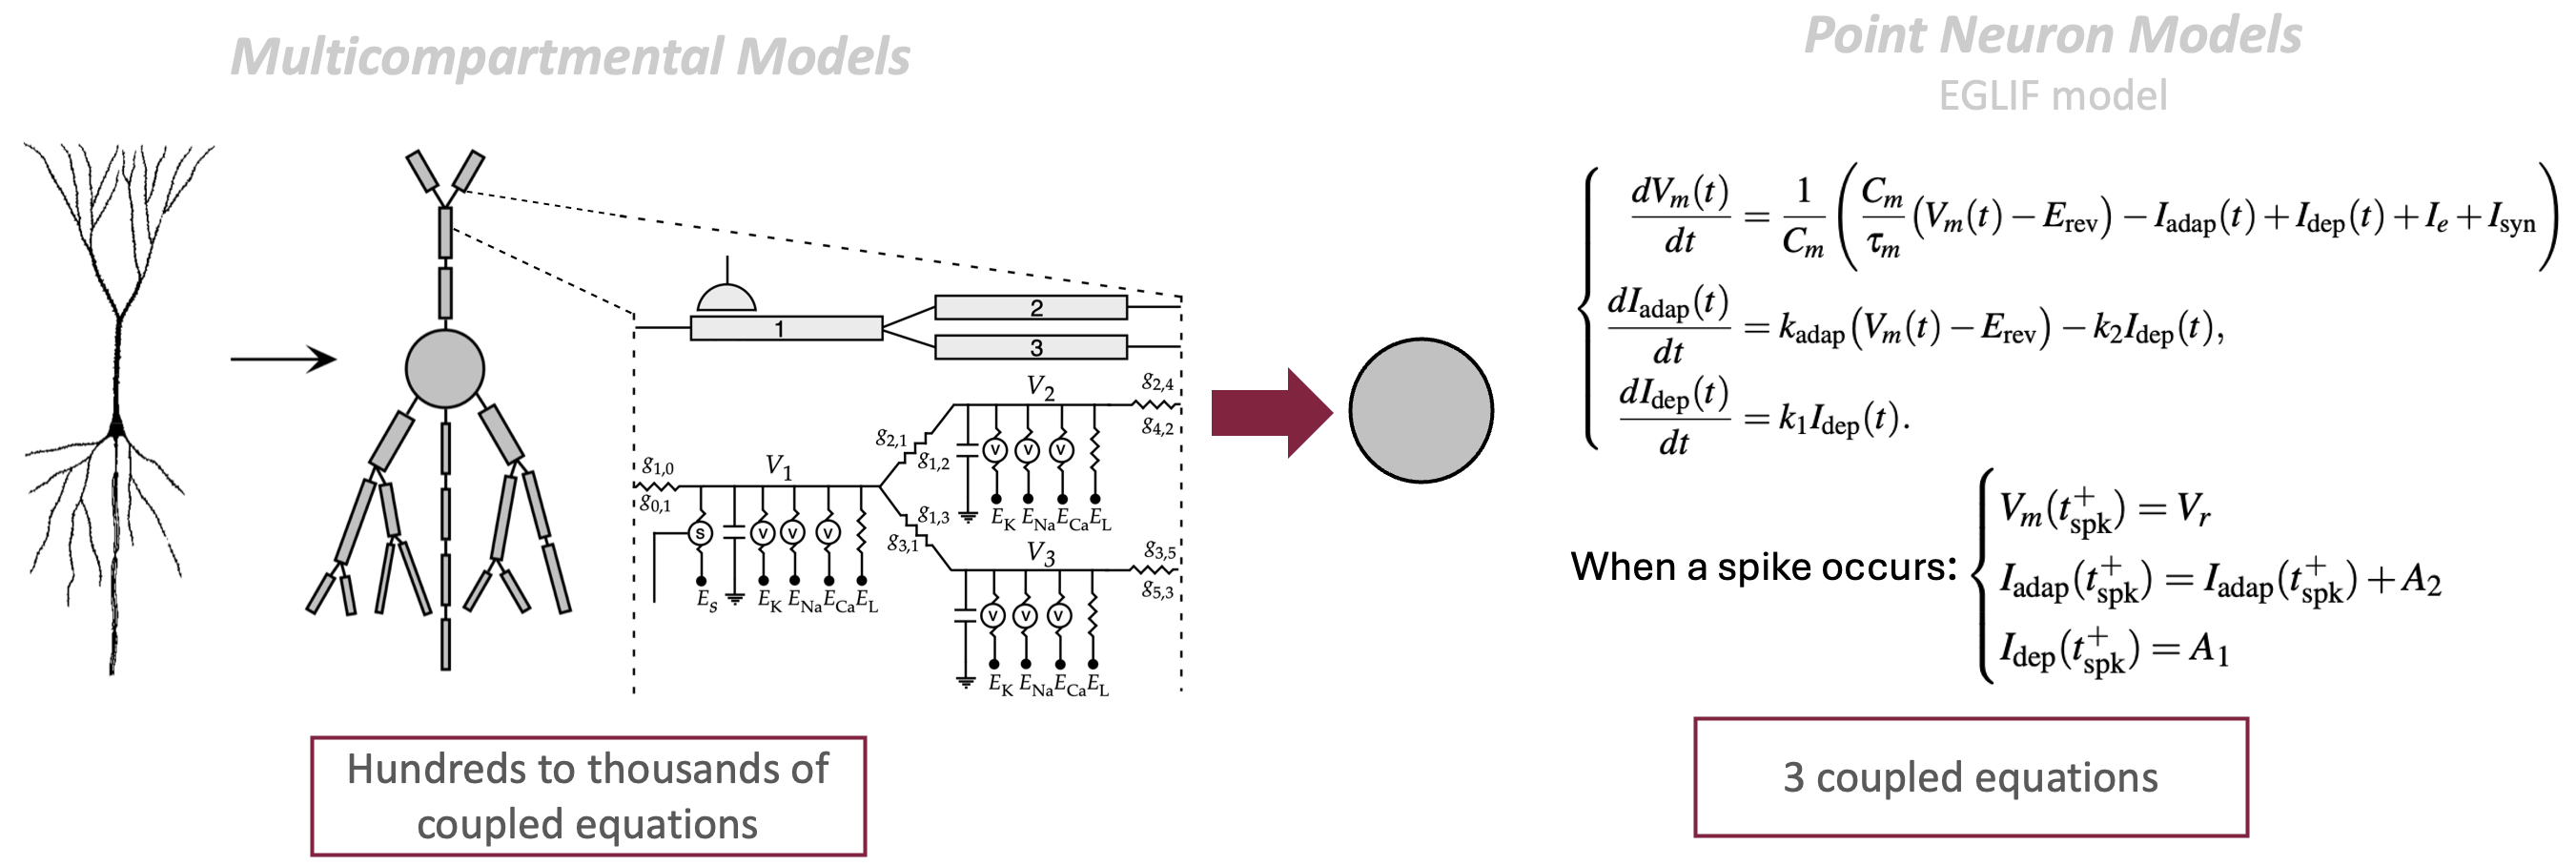

In [95]:
display(Image('figs/fig4.png'))

For this task, we will use the **NEST simulator** ([documentation](https://nest-simulator.readthedocs.io/en/stable/)), a Python-based simulation framework for point-neuron models. NEST can import a custom implementation of the **EGLIF model**, so the numerical integration of its equations is handled automatically by the simulator.

The optimization workflow is implemented within the [cerebellar-models](https://cerebellar-models.readthedocs.io/en/latest/) package developed by the DBBS Lab at the University of Pavia:

1. **Simulation**
   Simulate both the reference **multicompartmental model** and the **EGLIF model** under the same current-injection protocols.

2. **Feature extraction**
   Extract multiple electrophysiological features from the resulting spike trains for both models.

3. **Fitness evaluation**
   Compute fitness functions that quantify the agreement between the multicompartmental and EGLIF responses across the selected electrophysiological features.

4. **Parameter optimization**
   Optimize the tunable EGLIF parameters to identify the parameter set that best reproduces the electrophysiological response of the reference multicompartmental model.


In [96]:
def parse_current_from_filename(fname):
    m = re.search(r"inj(-?\d+(?:\.\d+)?)", fname)
    return float(m.group(1)) if m else np.nan

def list_available_currents(data_folder):
    files = [f for f in os.listdir(data_folder) if f.endswith(".txt")]
    return sorted({parse_current_from_filename(f) for f in files if not np.isnan(parse_current_from_filename(f))})

def load_trace(data_folder, current):
    files = [f for f in os.listdir(data_folder) if f.endswith(".txt")]
    match = [f for f in files if np.isclose(parse_current_from_filename(f), current)]
    if not match:
        raise ValueError(f"No file found for I={current} pA. Available currents: {list_available_currents(data_folder)}")
    data = np.loadtxt(os.path.join(data_folder, match[0]))
    return data[:, 0].astype(float), data[:, 1].astype(float)

Multicompartmental simulation results for a new **Purkinje Cell Zebrin + (Z+)** model we are exploring are already stored in .txt files, which we can visualize and use to reconstruct the fI curve for this cell type.

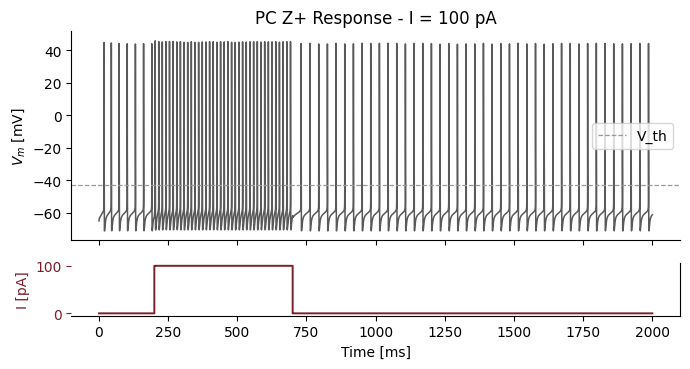

In [97]:
data_folder = "optimization/PC"
current = 100.0
start, stop = 200, 700

t, v = load_trace(data_folder, current)

fig, (axV, axI) = plt.subplots(
    2, 1, figsize=(7, 3.8), sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}
)

axV.plot(t, v, color="0.35", linewidth=1.1)
axV.axhline(y=-43.0, color="0.6", linestyle="--", linewidth=0.9, label='V_th')
axV.set_ylabel(r"$V_m$ [mV]")
axV.set_title(f"PC Z+ Response - I = {current:g} pA")
axV.spines["top"].set_visible(False)
axV.spines["right"].set_visible(False)
axV.legend()

I = np.zeros_like(t)
I[(t >= start) & (t <= stop)] = current
axI.plot(t, I, drawstyle="steps-post", color="#7a1f2b", linewidth=1.4)
axI.set_ylabel("I [pA]", color="#7a1f2b")
axI.set_xlabel("Time [ms]")
axI.spines["top"].set_visible(False)
axI.spines["left"].set_visible(False)
axI.tick_params(axis="y", colors="#7a1f2b")

plt.tight_layout()
plt.show()

In [98]:
# You can extract various feature from the voltage trace

from cerebellar_models.optimization.features import multicomp_features

threshold = -43.0
multicomp_features = multicomp_features(
    data_folder, threshold=threshold, start_stim=start, end_stim=stop
)

multicomp_features

/usr/local/lib/python3.13/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning:Error while calculating adaptation_index, Parameter [offset] is missing in the map. In the python interface, this can be set using the appropriate setting function
Parameter [offset] is missing in the map. In the python interface, this can be set using the appropriate setting function
Parameter [offset] is missing in the map. In the python interface, this can be set using the appropriate setting function
Parameter [offset] is missing in the map. In the python interface, this can be set using the appropriate setting function
Parameter [offset] is missing in the map. In the python interface, this can be set using the appropriate setting function
An error occurred while computing the feature, feature is not found. Minimum 4 spikes needed for feature [adaptation_index].
/usr/local/lib/python3.13/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning:Error while calculating adaptat

,current,peak_time,time_to_first_spike,time_to_second_spike,time_to_last_spike,inv_first_ISI,inv_second_ISI,inv_third_ISI,inv_fourth_ISI,inv_fifth_ISI,inv_last_ISI,ISI_log_slope,ISI_CV,adaptation_index,spike_count_stimint,mean_frequency
0,-900.0,"[18.499999999999993, 44.600000000000364, 72.90...",[-181.5],[-155.39999999999964],[1798.0999999992782],[38.314176245210184],[35.33568904593668],[34.2465753424677],[33.898305084747676],[33.7837837837857],[32.467532467561995],[-0.045493364680629346],[1.782849275588998],None,[0],0.0
1,-600.0,"[18.499999999999993, 44.600000000000364, 72.90...",[-181.5],[-155.39999999999964],[1775.9999999992983],[38.314176245210184],[35.33568904593668],[34.2465753424677],[33.898305084747676],[33.7837837837857],[32.467532467561995],[-0.05581636434095475],[1.7855225099327752],None,[0],0.0
2,-300.0,"[18.499999999999993, 44.600000000000364, 72.90...",[-181.5],[-155.39999999999964],[1782.3999999992925],[38.314176245210184],[35.33568904593668],[34.2465753424677],[33.898305084747676],[33.7837837837857],[32.467532467561995],[-0.06357318602619516],[1.7711748399601985],None,[0],0.0
3,-200.0,"[18.499999999999993, 44.600000000000364, 72.90...",[-181.5],[-155.39999999999964],[1782.0999999992928],[38.314176245210184],[35.33568904593668],[34.2465753424677],[33.898305084747676],[33.7837837837857],[32.467532467561995],[-0.06513303481989516],[1.76120093796389],None,[0],0.0
4,-100.0,"[18.499999999999993, 44.600000000000364, 72.90...",[-181.5],[-155.39999999999964],[1778.6999999992959],[38.314176245210184],[35.33568904593668],[34.2465753424677],[33.898305084747676],[33.7837837837857],[32.467532467561995],[-0.06663630501332243],[1.742568826923779],None,[0],0.0
5,0.0,"[18.499999999999993, 44.600000000000364, 72.90...",[18.499999999999993],[44.600000000000364],[1994.4999999992815],[38.314176245210184],[35.33568904593668],[34.2465753424677],[33.898305084747676],[33.7837837837857],[32.1543408360421],[0.019646206115571697],[0.017796339205929153],[0.0005083786659961471],[66],33.0
6,100.0,"[18.499999999999993, 44.600000000000364, 72.90...",[-181.5],[-155.39999999999964],[1786.199999999289],[38.314176245210184],[35.33568904593668],[34.2465753424677],[33.898305084747676],[33.7837837837857],[31.74603174606062],[0.20366467636160973],[0.39455111762048395],[0.0003355083499748485],[38],76.0
7,200.0,"[18.499999999999993, 44.600000000000364, 72.90...",[-181.5],[-155.39999999999964],[1783.999999999291],[38.314176245210184],[35.33568904593668],[34.2465753424677],[33.898305084747676],[33.7837837837857],[31.645569620281947],[0.24527887331554657],[0.5549110570720313],[0.0003307419530854021],[51],102.0
8,300.0,"[18.499999999999993, 44.600000000000364, 72.90...",[-181.5],[-155.39999999999964],[1791.2999999992844],[38.314176245210184],[35.33568904593668],[34.2465753424677],[33.898305084747676],[33.7837837837857],[31.446540880531746],[0.26216542942555593],[0.649029292649222],[0.0002139574629105533],[61],122.0
9,400.0,"[18.499999999999993, 44.600000000000364, 72.90...",[-181.5],[-155.39999999999964],[1769.699999999304],[38.314176245210184],[35.33568904593668],[34.2465753424677],[33.898305084747676],[33.7837837837857],[31.25000000002842],[0.2634990291534148],[0.7261665808162566],[0.0002136855187274928],[69],138.0


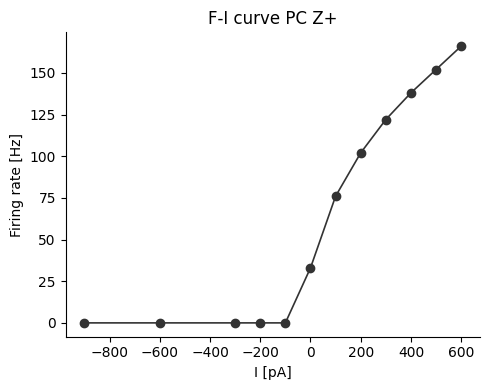

In [99]:
plt.figure(figsize=(5, 4))
plt.plot(multicomp_features["current"], multicomp_features["mean_frequency"], marker="o", color="0.2", linewidth=1.2)
plt.xlabel("I [pA]")
plt.ylabel("Firing rate [Hz]")
plt.title("F-I curve PC Z+")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

Now we can repeat the same experiment in the NEST simulator using our point neuron model EGLIF, and define the **multi-objective optimization problem**, with an objective functions based on the electrophysiological features of the detailed model that we want to preserve. In this simple example, we will mainly optimize the fI curve response in terms of rheobase, slope, and point-by-point agreement.

In [100]:
import nest
from scipy.optimize import differential_evolution

from cerebellar_models.optimization.features import multicomp_features, point_neuron_features
from cerebellar_models.optimization.fitness import (
    pacemaking_loss, cv_loss, rheobase_loss, currents_above_thr,
    curvature_loss, gap_loss, post_first_spike_loss, post_rebound_loss
)

In [101]:
def reset_nest():
    nest.ResetKernel()
    nest.set_verbosity("M_ERROR")
    nest.Install('cerebmodule')

def run_nest_batch(nest_model, inj_currents, protocol, cell_params):
    spike_trains = []
    for curr in inj_currents:
        reset_nest()
        nrn = nest.Create(nest_model, params=cell_params)
        sr = nest.Create("spike_recorder")
        nest.Connect(nrn, sr)

        if curr != 0:
            stim = nest.Create("step_current_generator", params={
                "amplitude_times": [protocol["start_stim"], protocol["end_stim"]],
                "amplitude_values": [float(curr), 0.0],
            })
            nest.Connect(stim, nrn)

        nest.Simulate(protocol["duration"])
        spike_trains.append(sr.get("events")["times"])
    return spike_trains

In [102]:
def plot_fi_curves(target_features, nest_features, labels=("target", "nest model")):
    fig, ax = plt.subplots(figsize=(5, 4))

    for feats, lab in zip([target_features, nest_features], labels):
        ax.plot(feats["current"], feats["mean_frequency"], marker="o", linewidth=1.2, label=lab)

    ax.set_xlabel("I [pA]")
    ax.set_ylabel("Firing rate [Hz]")
    ax.set_title("F-I curve")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend()
    plt.tight_layout()
    return fig

/usr/local/lib/python3.13/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning:Error while calculating adaptation_index, Parameter [offset] is missing in the map. In the python interface, this can be set using the appropriate setting function
Parameter [offset] is missing in the map. In the python interface, this can be set using the appropriate setting function
Parameter [offset] is missing in the map. In the python interface, this can be set using the appropriate setting function
Parameter [offset] is missing in the map. In the python interface, this can be set using the appropriate setting function
Parameter [offset] is missing in the map. In the python interface, this can be set using the appropriate setting function
An error occurred while computing the feature, feature is not found. Minimum 4 spikes needed for feature [adaptation_index].
/usr/local/lib/python3.13/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning:Error while calculating adaptat

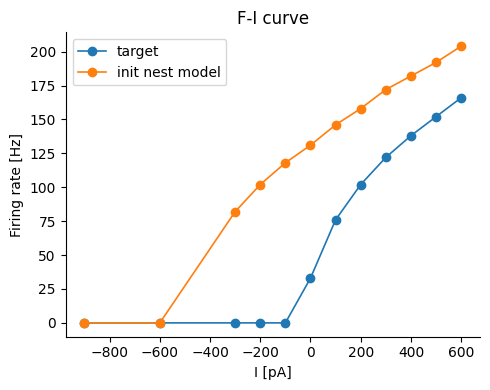

In [ ]:
# PC initial parameters
cell_params = {
    "A1": 1700,
    "A2": 3,
    "C_m": 334,
    "E_L": -59,
    "I_e": 100.0,
    "V_m": -59.0,
    "V_min": -350,
    "V_reset": -69,
    "V_th": -43,
    "k_1": 0.1,
    "k_2": 0.03,
    "k_adap": 0.25,
    "t_ref": 0.5,
    "tau_m": 47,
}

protocol = {"start_stim": 200.0, "end_stim": 700.0, "duration": 2000.0, "threshold": cell_params["V_th"]}
nest_model = "eglif_multirec"

target_features = multicomp_features(
    data_folder, threshold=threshold, start_stim=start, end_stim=stop
)

inj_currents = target_features["current"].values

spike_trains_opt = run_nest_batch(nest_model, inj_currents, protocol, cell_params)

nest_features_init = point_neuron_features(
    spike_trains=spike_trains_opt, currents=inj_currents,
    start_stim=protocol["start_stim"], end_stim=protocol["end_stim"],
    duration=protocol["duration"],
)
fig = plot_fi_curves(target_features, nest_features_init, labels=["target", "init nest model"])

In [ ]:
opt_params = ["I_e", "k_adap", "k_2", "A1", "A2", "k_1"]

# select boundary for optimization problem
bounds_dict = {
    "I_e": (0., 200.),
    "k_adap": (0., 0.50),
    "k_2": (0.01, 0.040),
    "A1": (1500, 2000.0),
    "A2": (2., 5.),
    "k_1": (0.01, 0.3),
}

bounds = [bounds_dict[p] for p in opt_params]

x0 = [cell_params[p] for p in opt_params]
print(dict(zip(opt_params, bounds)))

{'I_e': (0.0, 200.0), 'k_adap': (0.0, 0.5), 'k_2': (0.01, 0.04), 'A1': (1500, 2000.0), 'A2': (2.0, 5.0), 'k_1': (0.01, 0.3)}


In [ ]:
def cell_obj_function(x, target_features, protocol, cell_params, opt_params, nest_model):
    loc_cell_params = cell_params.copy()
    for name, val in zip(opt_params, x):
        loc_cell_params[name] = float(val)

    inj_currents = target_features["current"].values
    spike_trains = run_nest_batch(nest_model, inj_currents, protocol, loc_cell_params)
    nest_features = point_neuron_features(
        spike_trains=spike_trains, currents=inj_currents,
        start_stim=protocol["start_stim"], end_stim=protocol["end_stim"],
        duration=protocol["duration"],
    )

    # features to consider
    # Pacemaking: mean spontaneous firing rate
    pace = pacemaking_loss(target_features, nest_features)
    # Coeffiecient of variation
    cv_err = cv_loss(target_features, nest_features)
    rheo, thr = rheobase_loss(nest_features, target_features)
    sel = currents_above_thr(target_features, thr)
    curv = curvature_loss(target_features, nest_features, sel, use_max_slope_penalty=True)
    gap = gap_loss(target_features, nest_features, sel, weighted="gaussian")

    terms = [pace, cv_err, rheo, curv, gap]
    if np.any(np.isnan(terms)):
        return 7.0
    return float(np.sum(terms))

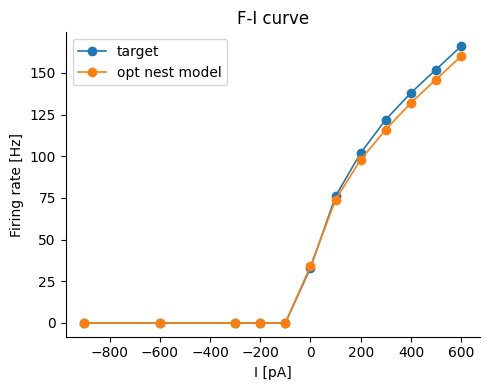

In [ ]:
cell_params_opt = cell_params.copy()
for name, val in zip(opt_params, res.x):
    cell_params_opt[name] = float(val)

inj_currents = target_features["current"].values
spike_trains_opt = run_nest_batch(nest_model, inj_currents, protocol, cell_params_opt)
nest_features_opt = point_neuron_features(
    spike_trains=spike_trains_opt, currents=inj_currents,
    start_stim=protocol["start_stim"], end_stim=protocol["end_stim"],
    duration=protocol["duration"],
)

fig = plot_fi_curves(target_features, nest_features_opt, labels=["target", "opt nest model"])
fig.show()

You can try to optimize another cell type, such as the GrC, whose simulation results, from the corresponding multicompartmental model, can be found in the folder optimization/GrC.
If you are interested in the full multi-objective optimization pipeline we developed, look [here](https://github.com/dbbs-lab/cerebellar-models/tree/feature/auto_mfm/eglif_tuning).